# 1. Exploratory analysis

This notebook looks at the raw recordings before any modelling: what was recorded, how clean it is, and what actually drives the signals.

The dataset is the Texas A&M leak-simulation benchmark (Aghashahi, Sela and Banks, 2023). A lab-scale PVC water network was run with four kinds of induced leak and a no-leak baseline, in two pipe layouts and four flow conditions, and recorded with two accelerometers, two dynamic pressure sensors and two hydrophones. Full details are in [DATASET.md](../DATASET.md).

Sections 1.3, 1.4, 1.7 and 1.8 read raw files and need the data downloaded. Everything else runs from the small files committed in the repository.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import leakdata as ld
import plotstyle as ps

ps.apply()
pd.set_option("display.width", 160)

inv = pd.read_csv("../file_inventory.csv")
inv["stype"] = inv.sensor.str[0]
psd = np.load(ld.PROCESSED / "psd.npz")
index = ld.build_index()
paths = index.set_index("file").path
print(len(inv), "recordings,", round(inv.bytes.sum() / 1e9, 2), "GB")

282 recordings, 3.88 GB


## 1.1 Experimental design

Number of recordings for each leak class under each flow condition, both pipe layouts combined.

In [2]:
labelled = inv[inv.leak != "BG"]
design = labelled.pivot_table(index=["stype", "flow"], columns="leak", values="file", aggfunc="count")
design = design.reindex(index=pd.MultiIndex.from_product([list("APH"), ld.FLOWS]), columns=ld.LEAKS)
design.rename(index=ld.SENSOR_NAMES, level=0).rename(columns=ld.LEAK_NAMES).rename_axis(index=["sensor type", "flow condition"], columns=None)

No-leak  Orifice leak  Longitudinal crack  Circumferential crack  Gasket leak
sensor type      flow condition                                                                               
Accelerometer    ND                    4             4                   4                      4            4
                 0.18 LPS              4             4                   4                      4            4
                 0.47 LPS              4             4                   4                      4            4
                 Transient             4             4                   4                      4            4
Dynamic pressure ND                    4             4                   4                      4            4
                 0.18 LPS              4             4                   4                      4            4
                 0.47 LPS              4             4                   4                      4            4
                 Transient             4             4                   4                      4            4
Hydrophone       ND                    8             8                   8                      8            8
                 0.18 LPS              4             4                   4                      4            4
                 0.47 LPS              4             4                   4                      4            4
                 Transient             8             8                   8                      8            8

The design is a complete, balanced grid. Accelerometer and pressure have four files per cell: two layouts times two sensors. The hydrophone has four per cell for the steady-flow conditions and eight for no-demand and transient, because those were recorded both with and without added background noise.

The important limitation is visible here: **every cell is a single physical test**. There are 40 tests in total (2 layouts x 5 classes x 4 flows) and no repeats. Whatever a model learns about a class, it learns from 8 tests.

## 1.2 Recording length and data quality

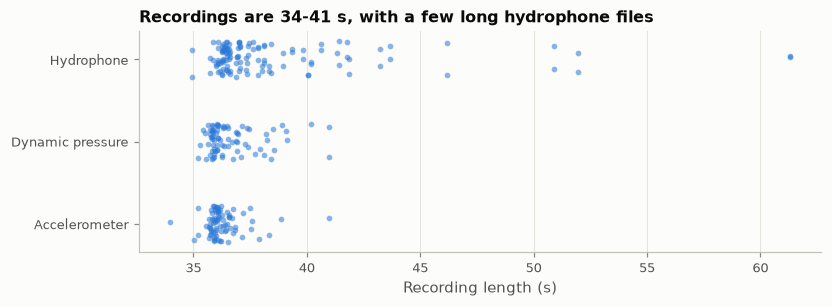

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.6))
rng = np.random.default_rng(0)
for i, st in enumerate("APH"):
    d = inv[inv.stype == st].dur_s
    ax.scatter(d, i + rng.uniform(-0.22, 0.22, len(d)), s=14, color="#2a78d6", alpha=0.55, linewidths=0)
ax.set_yticks(range(3), [ld.SENSOR_NAMES[s] for s in "APH"])
ax.set_xlabel("Recording length (s)")
ax.set_title("Recordings are 34-41 s, with a few long hydrophone files")
ax.grid(axis="y", visible=False)
plt.show()

In [4]:
pair = labelled.assign(key=labelled.file.str.replace(r"_[APH][12]\.(csv|raw)$", "", regex=True))
g = pair.groupby(["stype", "key"]).n.agg(["min", "max"])
g["diff_s"] = (g["max"] - g["min"]) / g.index.get_level_values(0).map(ld.FS)
quality = pd.DataFrame(
    {
        "recordings": inv.groupby("stype").size(),
        "missing values": inv.groupby("stype").nan.sum(),
        "rows at Excel limit (1,048,572)": inv[inv.n == 1048572].groupby("stype").size(),
        "files reaching 16-bit limits": inv[(inv["max"] >= 32767) | (inv["min"] <= -32768)].groupby("stype").size(),
        "sensor pairs": g.groupby("stype").size(),
        "pairs of equal length": (g.diff_s == 0).groupby("stype").sum(),
        "largest pair length gap (s)": g.groupby("stype").diff_s.max().round(2),
    }
).fillna(0).astype({"rows at Excel limit (1,048,572)": int, "files reaching 16-bit limits": int})
quality.rename(index=ld.SENSOR_NAMES).T

stype,Accelerometer,Hydrophone,Dynamic pressure
recordings,80.00,122.00,80.00
missing values,0.00,0.00,0.00
"rows at Excel limit (1,048,572)",1.00,0.00,2.00
files reaching 16-bit limits,0.00,44.00,0.00
sensor pairs,40.00,60.00,40.00
pairs of equal length,0.00,59.00,0.00
largest pair length gap (s),4.23,3.88,4.91


Four things to carry forward:

- **No missing values** in any file.
- **Three CSV files stop at exactly 1,048,572 rows**, just under the Excel worksheet limit, so they were probably truncated on export. They are still about 41 s long, so they are kept.
- **Hydrophone clipping.** 44 of 122 hydrophone files reach the 16-bit limits, almost all of them transient recordings.
- **Sensor 1 and sensor 2 are not sample-aligned.** No accelerometer or pressure pair has matching length. That rules out leak localisation by cross-correlating the two sensors without first re-aligning them, so localisation is out of scope here.

## 1.3 What the signals look like

One test condition (looped layout, 0.47 L/s demand), accelerometer A2, all five classes. Left: the whole recording. Right: a 40 ms close-up.

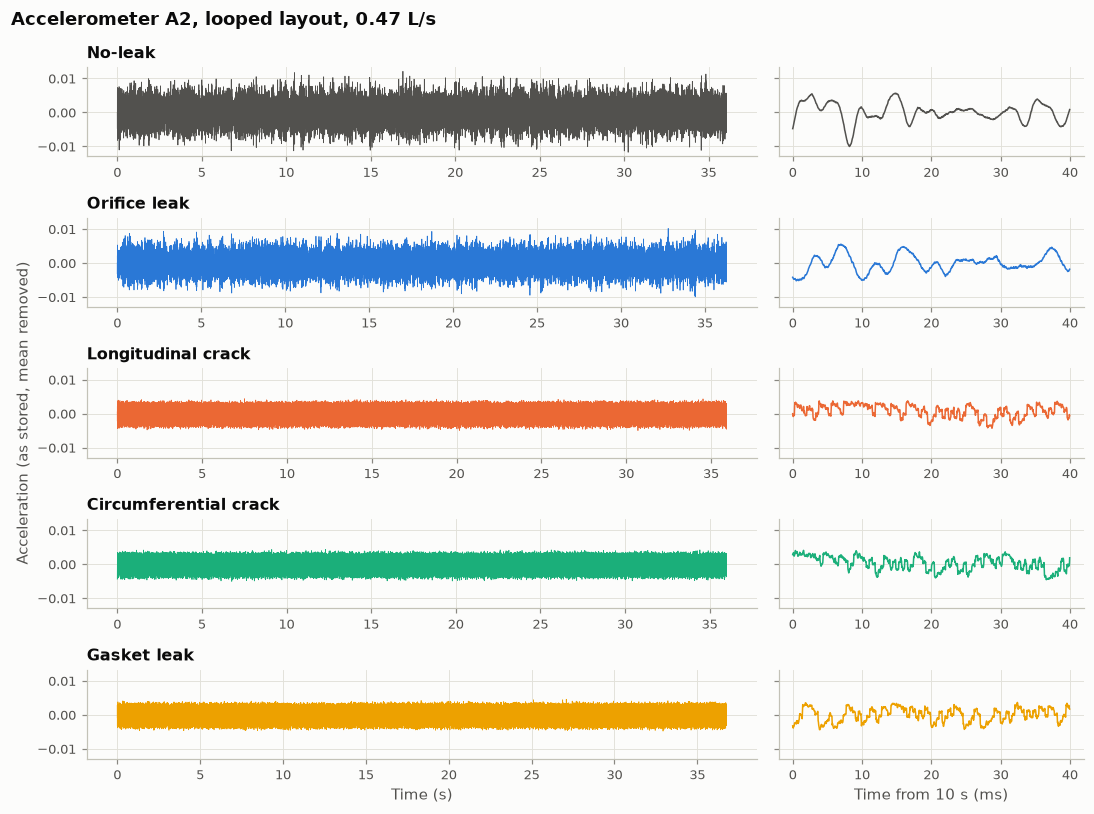

In [5]:
fig, axes = plt.subplots(5, 2, figsize=(10, 7.5), sharey=True, gridspec_kw={"width_ratios": [2.2, 1]})
for row, leak in enumerate(ld.LEAKS):
    x, fs = ld.load_signal(paths[f"LO_{leak}_0.47 LPS_A2.csv"])
    x = x - x.mean()
    t = np.arange(x.size) / fs
    c = ps.LEAK_COLORS[leak]
    axes[row, 0].plot(t[::20], x[::20], color=c, lw=0.5)
    z = slice(10 * fs, 10 * fs + int(0.04 * fs))
    axes[row, 1].plot((t[z] - 10) * 1000, x[z], color=c, lw=1.0)
    axes[row, 0].set_title(ld.LEAK_NAMES[leak], color=ps.INK)
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time from 10 s (ms)")
axes[2, 0].set_ylabel("Acceleration (as stored, mean removed)")
fig.suptitle("Accelerometer A2, looped layout, 0.47 L/s", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

The steady-flow signals are stationary noise-like vibration: there is no event to find, so the information has to come from the spectrum and the statistics of the signal. In the close-up, the three crack and gasket classes carry visibly finer, higher-frequency ripple than no-leak and orifice leak. Sections 1.5 and 1.7 show that this difference is not what it seems.

## 1.4 The transient condition

In the transient tests, demand is shut off from 0.47 L/s to zero part-way through. The same no-leak test seen by four sensors:

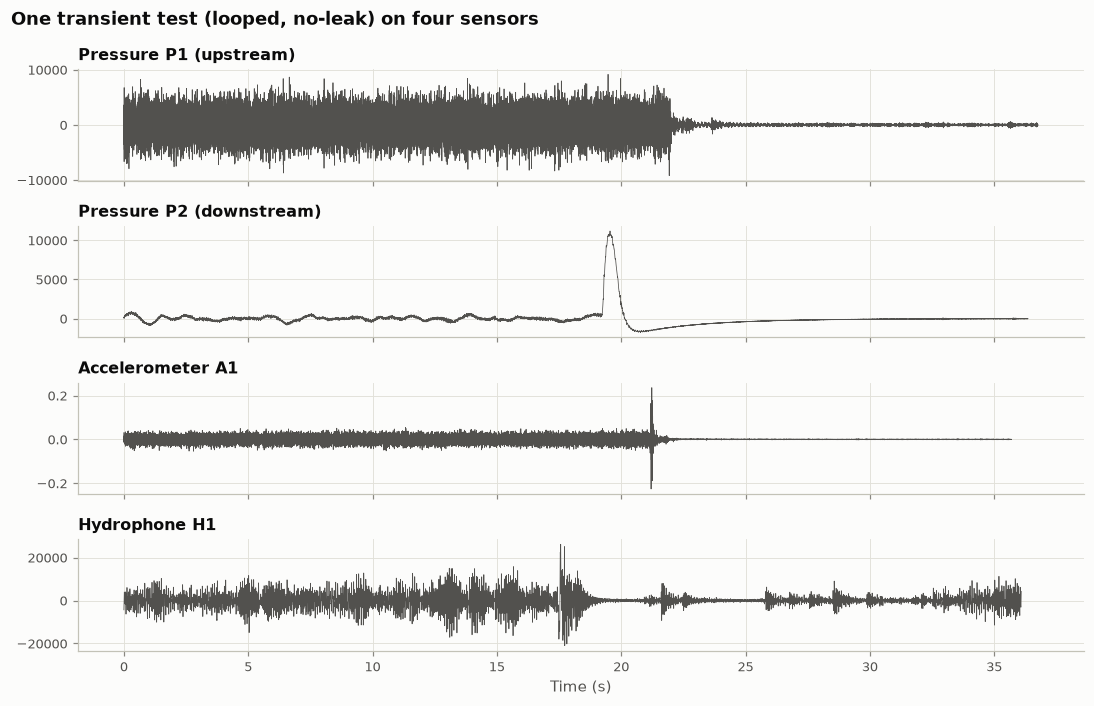

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 6.5), sharex=True)
for ax, (name, label) in zip(
    axes,
    [("LO_NL_Transient_P1.csv", "Pressure P1 (upstream)"), ("LO_NL_Transient_P2.csv", "Pressure P2 (downstream)"),
     ("LO_NL_Transient_A1.csv", "Accelerometer A1"), ("LO_NL_Transient_N_H1.raw", "Hydrophone H1")],
):
    x, fs = ld.load_signal(paths[name])
    x = x - x.mean()
    step = max(1, fs // 1600)
    ax.plot(np.arange(x.size)[::step] / fs, x[::step], color=ps.LEAK_COLORS["NL"], lw=0.5)
    ax.set_title(label)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("One transient test (looped, no-leak) on four sensors", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

In [7]:
tr = labelled[labelled.flow == "Transient"]
print("Median excess kurtosis, transient vs steady conditions")
print(labelled.assign(transient=labelled.flow == "Transient").pivot_table(index="sensor", columns="transient", values="kurt", aggfunc="median").round(2).to_string())

Median excess kurtosis, transient vs steady conditions
transient  False  True 
sensor                 
A1          0.03   2.26
A2          0.04   0.40
H1         -0.04   2.55
H2         -0.05  10.03
P1         -0.05   0.71
P2         -0.08  43.74


The shut-off appears as a pressure surge at about 20 s, which matches the published procedure. It is by far the largest feature in those recordings, and it is unrelated to whether a leak is present. Transient recordings are therefore non-stationary in a way the other three conditions are not. The four streams are separate files with no shared clock, so the event does not line up exactly between them.

## 1.5 Frequency content by leak class

Each panel is one sensor in one pipe layout. Each line is the median power spectrum of one leak class across the four flow conditions.

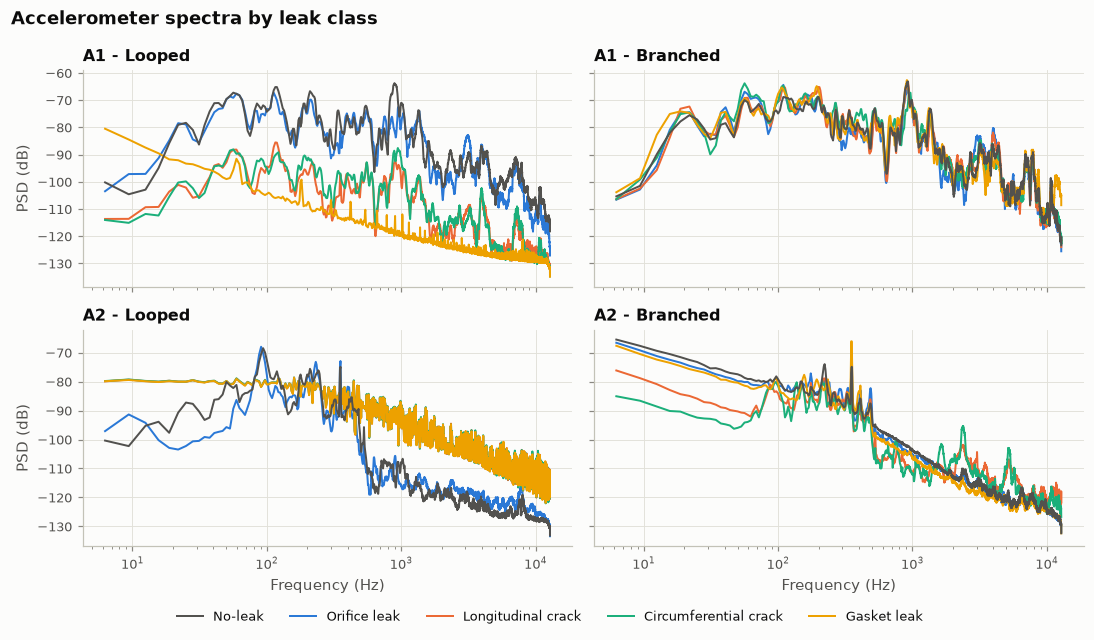

In [8]:
def psd_table(stype):
    files = psd[f"{stype}_file"]
    meta = inv.set_index("file").loc[files].reset_index()
    return psd[f"{stype}_f"], 10 * np.log10(psd[f"{stype}_pxx"] + 1e-30), meta

def psd_grid(sensors, fmin, title):
    fig, axes = plt.subplots(len(sensors), 2, figsize=(10, 2.9 * len(sensors)), sharex=True, sharey="row")
    for r, sensor in enumerate(sensors):
        f, db, meta = psd_table(sensor[0])
        keep = f >= fmin
        for c, topo in enumerate(["LO", "BR"]):
            ax = axes[r, c]
            for leak in ld.LEAKS:
                m = ((meta.sensor == sensor) & (meta.topology == topo) & (meta.leak == leak)).to_numpy()
                ax.plot(f[keep], np.median(db[m], axis=0)[keep], color=ps.LEAK_COLORS[leak], lw=1.3,
                        label=ld.LEAK_NAMES[leak], zorder=3 if leak == "NL" else 2)
            ax.set_xscale("log")
            ax.set_title(f"{sensor} - {ld.TOPOLOGIES[topo]}")
            if c == 0:
                ax.set_ylabel("PSD (dB)")
    for ax in axes[-1]:
        ax.set_xlabel("Frequency (Hz)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(title, x=0.01, ha="left", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()

psd_grid(["A1", "A2"], 5, "Accelerometer spectra by leak class")

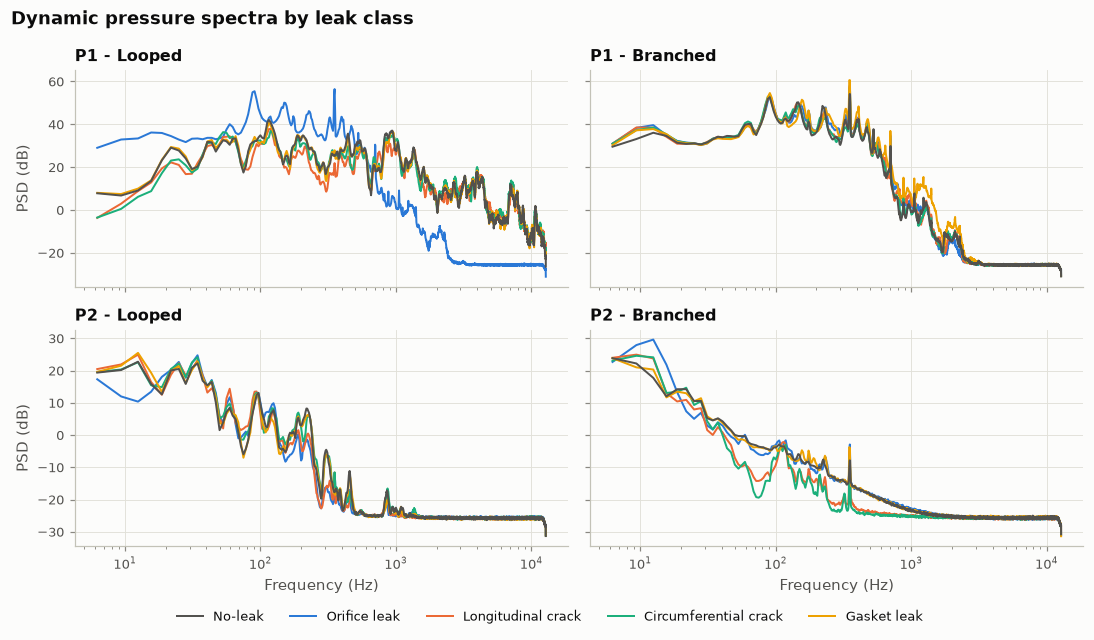

In [9]:
psd_grid(["P1", "P2"], 5, "Dynamic pressure spectra by leak class")

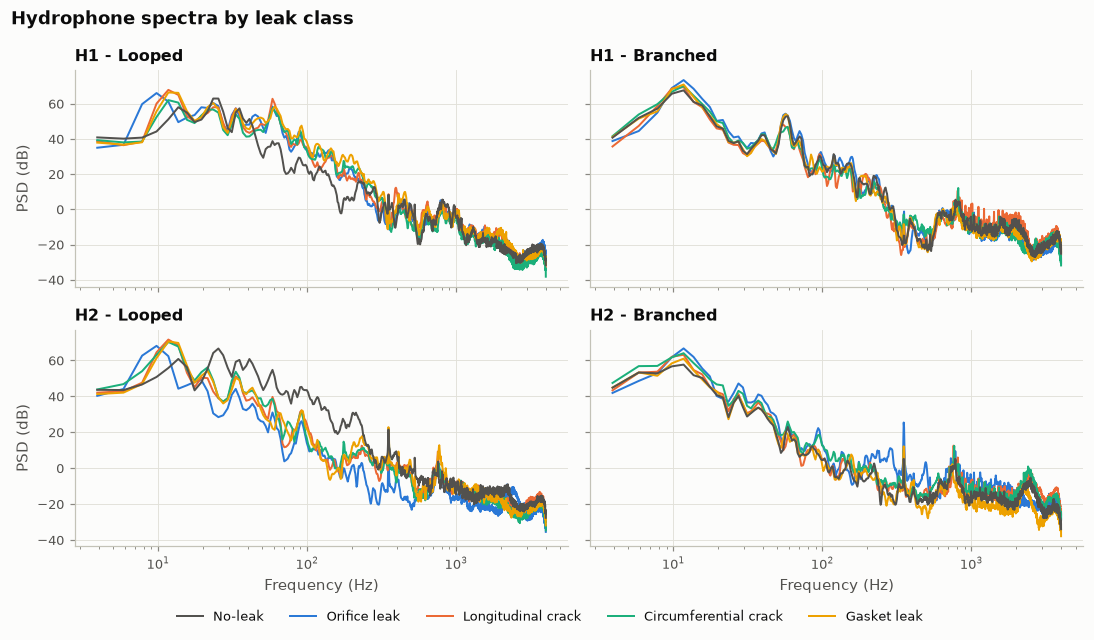

In [10]:
psd_grid(["H1", "H2"], 2, "Hydrophone spectra by leak class")

Three things stand out.

- **Branched layout: the five classes are almost indistinguishable on every sensor.** The lines sit within a few dB of each other across the whole spectrum. Whatever these small leaks (a 1.6 mm hole, 2 mm x 1 mm cracks) add to the signal, it is small next to the flow noise of the rig.
- **Looped layout: the classes fall into groups, not five signatures.** On both accelerometers, no-leak and orifice leak overlap, while the two cracks and the gasket leak form a second group that is about 20 dB quieter on A1 and has a flat, featureless spectrum on A2. On pressure sensor P1 it is the orifice leak alone that differs. On the hydrophones it is no-leak alone.
- **The grouping changes from sensor to sensor and disappears in the other layout.** A physical leak signature should not behave like that. It looks more like the rig or the instrumentation being in a different state when different classes were recorded.

Section 1.7 looks at the looped accelerometer recordings more closely.

## 1.6 What drives signal level

Each dot is one recording. Panels are sensors; within a panel the two pipe layouts sit side by side for each leak class.

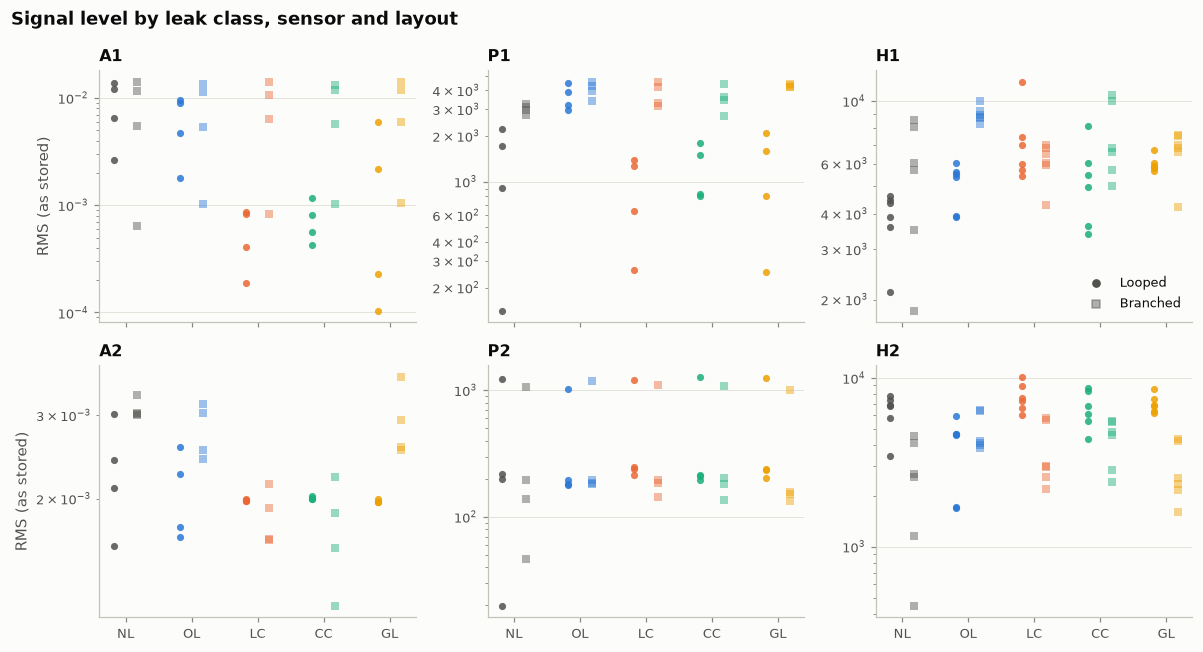

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True)
order = ["A1", "P1", "H1", "A2", "P2", "H2"]
for ax, sensor in zip(axes.ravel(), order):
    d = labelled[labelled.sensor == sensor]
    for i, leak in enumerate(ld.LEAKS):
        for j, (topo, marker) in enumerate([("LO", "o"), ("BR", "s")]):
            v = d[(d.leak == leak) & (d.topology == topo)].rms_ac
            ax.scatter(np.full(len(v), i + (j - 0.5) * 0.36), v, s=22, marker=marker, color=ps.LEAK_COLORS[leak],
                       alpha=0.85 if topo == "LO" else 0.45, linewidths=0)
    ax.set_yscale("log")
    ax.set_xticks(range(5), ld.LEAKS)
    ax.set_title(sensor)
    ax.grid(axis="x", visible=False)
axes[0, 0].set_ylabel("RMS (as stored)")
axes[1, 0].set_ylabel("RMS (as stored)")
axes[0, 2].scatter([], [], marker="o", color=ps.INK_2, s=22, label="Looped")
axes[0, 2].scatter([], [], marker="s", color=ps.INK_2, s=22, alpha=0.45, label="Branched")
axes[0, 2].legend(loc="lower right")
fig.suptitle("Signal level by leak class, sensor and layout", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

In [12]:
def eta_squared(values, groups):
    """Share of variance explained by a single grouping factor."""
    values = np.asarray(values, float)
    grand = values.mean()
    between = sum(len(v) * (v.mean() - grand) ** 2 for _, v in pd.Series(values).groupby(np.asarray(groups)))
    return between / ((values - grand) ** 2).sum()

rows = []
for st in "APH":
    d = labelled[labelled.stype == st]
    y = np.log10(d.rms_ac)
    rows.append({"sensor type": ld.SENSOR_NAMES[st],
                 "sensor position": eta_squared(y, d.sensor),
                 "pipe layout": eta_squared(y, d.topology),
                 "flow condition": eta_squared(y, d.flow),
                 "leak class": eta_squared(y, d.leak),
                 "position x layout": eta_squared(y, d.sensor + d.topology)})
print("Share of variance in log RMS explained by each factor on its own")
print(pd.DataFrame(rows).set_index("sensor type").round(2).to_string())

Share of variance in log RMS explained by each factor on its own
                  sensor position  pipe layout  flow condition  leak class  position x layout
sensor type                                                                                  
Accelerometer                0.02         0.11            0.20        0.10               0.20
Dynamic pressure             0.56         0.03            0.14        0.02               0.65
Hydrophone                   0.09         0.04            0.08        0.08               0.30


Signal level is set mostly by where the sensor is and which layout it is in, not by the leak:

- **Pressure:** sensor position alone explains 56% of the variance in level, and leak class 2%. P1 sits at the pump end of the supply line and is roughly 15 times louder than P2.
- **Accelerometer:** leak class explains 10%, but that comes from A1 in the looped layout, where the crack and gasket recordings are about ten times quieter than no-leak and orifice leak. On A1 in the branched layout the classes overlap completely.
- **Hydrophone:** no single factor dominates; the combination of position and layout explains 30%.

A model given absolute level would mostly be learning which sensor and layout a window came from.

## 1.7 A recording artefact in the looped accelerometer data

Accelerometer A2, looped layout: RMS level and excess kurtosis for every leak class and flow condition.

In [13]:
a2 = labelled[(labelled.sensor == "A2") & (labelled.topology == "LO")]
view = pd.concat({"RMS x 1000": a2.pivot_table(index="leak", columns="flow", values="rms_ac") * 1000,
                  "excess kurtosis": a2.pivot_table(index="leak", columns="flow", values="kurt")}, axis=1)
view.reindex(ld.LEAKS).reindex(columns=ld.FLOWS, level=1).round(2)

RMS x 1000                             excess kurtosis                            
flow         ND 0.18 LPS 0.47 LPS Transient              ND 0.18 LPS 0.47 LPS Transient
leak                                                                                   
NL         1.59     2.11     3.01      2.41            0.60     0.03     0.04      7.21
OL         1.74     1.66     2.58      2.25            0.03     0.05    -0.12      0.46
LC         1.99     1.98     1.98      2.00           -0.96    -0.93    -0.96     -0.97
CC         2.00     2.03     2.00      2.01           -0.97    -0.90    -0.97     -0.98
GL         1.97     2.00     1.97      1.97           -0.96    -0.90    -0.95     -0.95

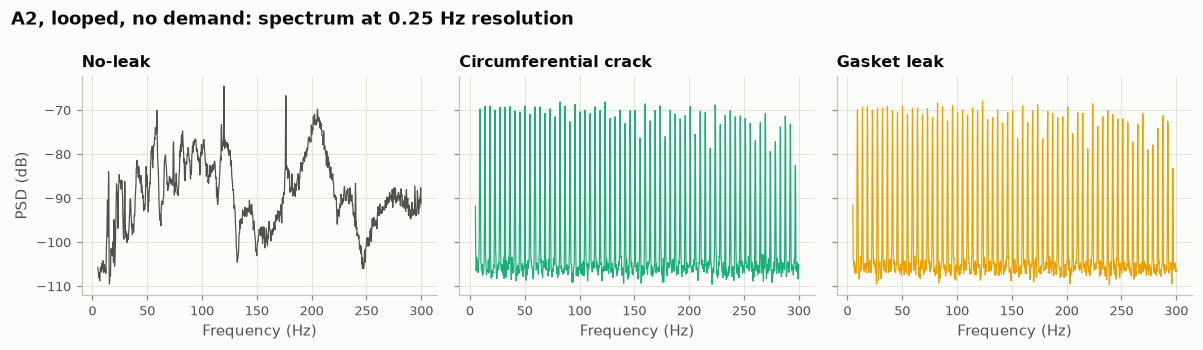

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, leak in zip(axes, ["NL", "CC", "GL"]):
    x, fs = ld.load_signal(paths[f"LO_{leak}_ND_A2.csv"])
    f, p = signal.welch(x - x.mean(), fs=fs, nperseg=fs * 4)
    keep = (f >= 5) & (f <= 300)
    ax.plot(f[keep], 10 * np.log10(p[keep]), color=ps.LEAK_COLORS[leak], lw=0.8)
    ax.set_title(ld.LEAK_NAMES[leak])
    ax.set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("PSD (dB)")
fig.suptitle("A2, looped, no demand: spectrum at 0.25 Hz resolution", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

In the looped layout, the twelve A2 recordings for the two cracks and the gasket leak do not behave like pipe vibration:

- **Their level is the same to within 3%** (1.97 to 2.03 on this scale) in every flow condition, including the transient, where every other sensor registers the demand shut-off.
- **Their excess kurtosis is about -0.95**, which is what a sum of steady tones gives, not flow noise (which is close to 0).
- **Their spectrum is a dense comb of narrow lines** on a flat floor, identical across the three classes.

A sensor that does not respond to flow or to a pressure surge is not measuring the pipe. The most likely explanation is that A2 was picking up electrical or instrumentation interference during those tests. A1 shows a related problem: the looped gasket-leak recordings sit near the noise floor, with a spectrum dominated by 60 Hz mains harmonics.

I cannot confirm the cause from the files alone. But the consequence is clear: **in the looped layout a classifier can separate cracks and gasket leaks from no-leak and orifice leak using the accelerometers, for reasons that have nothing to do with leaks.** The modelling notebook is designed to expose this instead of reporting it as accuracy.

## 1.8 Time-frequency view

Spectrograms of accelerometer A2 in the looped layout with no demand, for three classes, and of pressure sensor P2 during a transient.

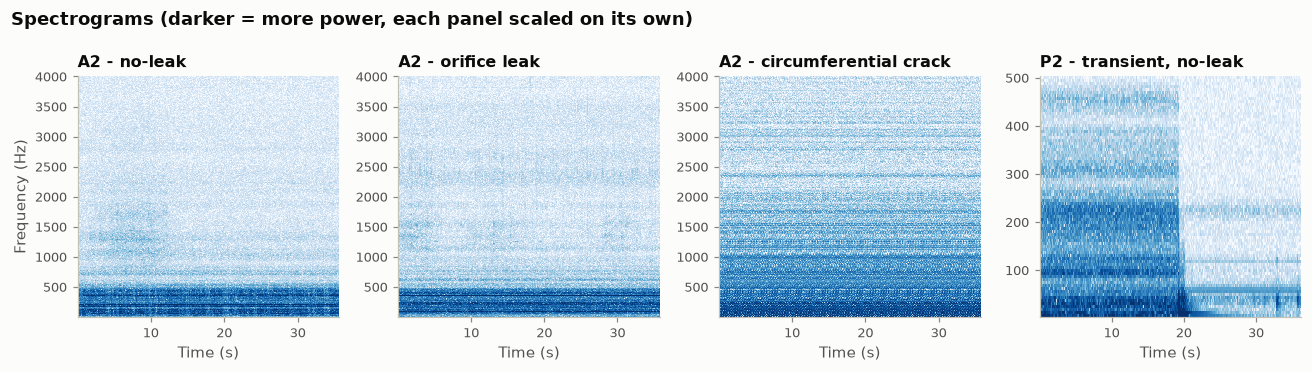

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4))
items = [("LO_NL_ND_A2.csv", "A2 - no-leak"), ("LO_OL_ND_A2.csv", "A2 - orifice leak"),
         ("LO_CC_ND_A2.csv", "A2 - circumferential crack"), ("LO_NL_Transient_P2.csv", "P2 - transient, no-leak")]
for ax, (name, title) in zip(axes, items):
    x, fs = ld.load_signal(paths[name])
    f, t, s = signal.spectrogram(x - x.mean(), fs=fs, nperseg=4096, noverlap=2048)
    keep = (f > 0) & (f <= (4000 if "A2" in name else 500))
    db = 10 * np.log10(s[keep] + 1e-30)
    im = ax.pcolormesh(t, f[keep], db, cmap=ps.SEQ_CMAP, vmin=np.percentile(db, 5), vmax=np.percentile(db, 99.5), shading="auto", rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.grid(False)
axes[0].set_ylabel("Frequency (Hz)")
fig.suptitle("Spectrograms (darker = more power, each panel scaled on its own)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

No-leak and orifice leak share the same texture: broadband energy below 500 Hz that drifts over time, as flow noise does. The circumferential crack recording is the comb from section 1.7: constant narrow lines up to 4 kHz with no variation in time. On the right, the pressure sensor shows flow noise switching off when demand is shut at about 20 s.

## 1.9 Hydrophone: background noise and the noise tag

Background-noise recordings, RMS: {'H1': 138.0, 'H2': 31.0}
Test recordings, median RMS:     {'H1': 6014.0, 'H2': 4710.0}


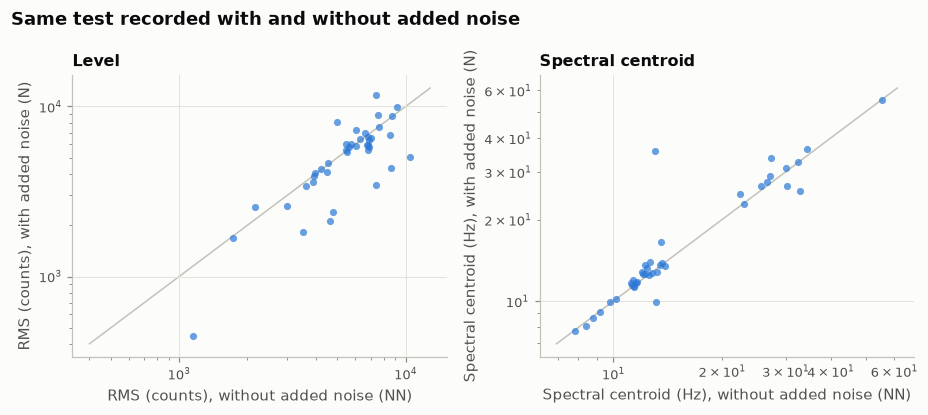

Median N/NN RMS ratio: 0.98  (interquartile range 0.86 to 1.02)

Hydrophone files reaching the 16-bit limits, by flow condition:
           sum  count
flow                 
ND           2     40
0.18 LPS     1     20
0.47 LPS     2     20
Transient   39     40


In [16]:
h = inv[inv.stype == "H"]
bg = h[h.leak == "BG"]
print("Background-noise recordings, RMS:", dict(zip(bg.sensor, bg.rms_ac.round(0))))
print("Test recordings, median RMS:    ", h[h.leak != "BG"].groupby("sensor").rms_ac.median().round(0).to_dict())

both = h[h.flow.isin(["ND", "Transient"])].pivot_table(index=["topology", "leak", "flow", "sensor"], columns="noise", values=["rms_ac", "f_centroid"])
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
for ax, col, label in zip(axes, ["rms_ac", "f_centroid"], ["RMS (counts)", "Spectral centroid (Hz)"]):
    a, b = both[col]["NN"], both[col]["N"]
    ax.scatter(a, b, s=22, color="#2a78d6", alpha=0.7, linewidths=0)
    lim = [min(a.min(), b.min()) * 0.9, max(a.max(), b.max()) * 1.1]
    ax.plot(lim, lim, color=ps.AXIS, lw=1, zorder=0)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(f"{label}, without added noise (NN)")
    ax.set_ylabel(f"{label}, with added noise (N)")
axes[0].set_title("Level")
axes[1].set_title("Spectral centroid")
fig.suptitle("Same test recorded with and without added noise", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()
ratio = np.log10(both["rms_ac"]["N"] / both["rms_ac"]["NN"])
print(f"Median N/NN RMS ratio: {10 ** ratio.median():.2f}  (interquartile range {10 ** ratio.quantile(0.25):.2f} to {10 ** ratio.quantile(0.75):.2f})")
clip = h[h.leak != "BG"].assign(clipped=lambda d: (d["max"] >= 32767) | (d["min"] <= -32768))
print("\nHydrophone files reaching the 16-bit limits, by flow condition:")
print(clip.groupby("flow").clipped.agg(["sum", "count"]).reindex(ld.FLOWS).to_string())

- **The hydrophones mostly hear the rig.** Test recordings are 40 to 150 times louder than the background-noise recordings, so the signal is dominated by flow and pump noise inside the pipe.
- **The added noise barely registers.** The same test with and without the traffic and saw noise gives nearly the same level (median ratio 0.98) and a similar spectrum. The `N` and `NN` files are therefore treated as two takes of the same test, and always kept on the same side of a train/test split.
- **Transient hydrophone recordings clip.** 39 of 40 reach the 16-bit limits.

## 1.10 Summary

1. **Complete and balanced, but thin.** 280 labelled recordings cover a full grid, with no missing values. There are only 40 physical tests and no repeats.
2. **Sensor position and pipe layout dominate the signals.** Leak class explains 2% of the variance in pressure level and 10% in accelerometer level.
3. **In the branched layout, the classes look the same** on every sensor.
4. **In the looped layout, classes differ in groups that look like recording sessions,** and the accelerometer recordings for cracks and gasket leaks contain a steady interference pattern instead of pipe vibration.
5. **Transient recordings are a different regime:** one large event unrelated to the leak, and clipped hydrophone data.

What this means for modelling:

- Splitting windows at random would test a model on recordings it has already seen. Splits must be by physical test.
- A high score inside the looped layout cannot be taken as leak detection. The test that matters is whether a model trained on one layout or flow condition works on another.
- Absolute signal level should be kept apart from spectral shape, so its contribution can be measured separately.